# Week2-1: 10D MCMC from scratch

Now we have the position of all the stars in the 1000x1000 pc on the sky. \
We assume that each star could belong ot the dwarf galaxy that follows a Gaussian distribution or a the MW forground that follows a flat distribution. \
Data space: spatial space (X, Y) + velocity space (v) \
Parameter space: (xc, yc, sigma_x, sigma_y, alpha, mvr_dg, dvr_dg, mvr_mw, dvr_mw, f)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import corner

%matplotlib inline

In [3]:
data_path = '../data/Dwarfs/'
res_path = '../result/'
fig_path = '../figure/'

k = 1
df = pd.read_csv(data_path+'Dwarf_%02d'%k)

df

,X_pc,Y_pc,vr,d_vr,FeH,d_FeH,flag
0,862.072,-267.376,-2.177,4.46,-2.13,0.23,1
1,-108.093,-117.081,999.000,999.00,-2.08,0.26,1
2,254.962,-410.536,999.000,999.00,-2.13,0.30,1
3,337.575,-492.211,999.000,999.00,-2.11,0.25,1
4,-329.291,-491.952,999.000,999.00,-2.44,0.25,1
...,...,...,...,...,...,...,...
2131,4776.443,976.284,999.000,999.00,-0.39,0.21,0
2132,4899.896,-3715.461,-55.157,4.43,-0.59,0.24,0
2133,-2399.821,-3014.935,999.000,999.00,-0.73,0.27,0
2134,56.823,2569.389,999.000,999.00,-0.77,0.24,0


## Check the data first

The dwarf galaxy looks very elliptical, so that we need more parameters!

(-2000.0, 2000.0)

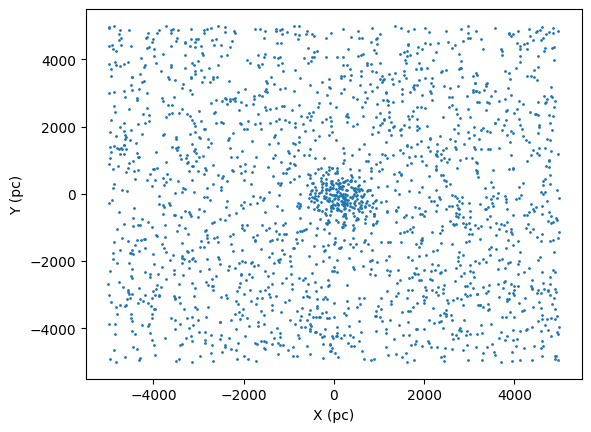

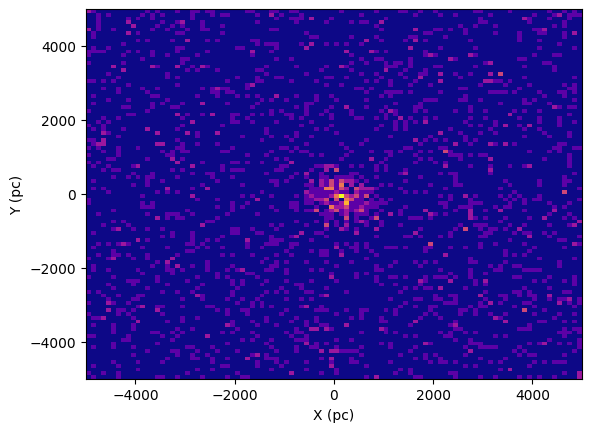

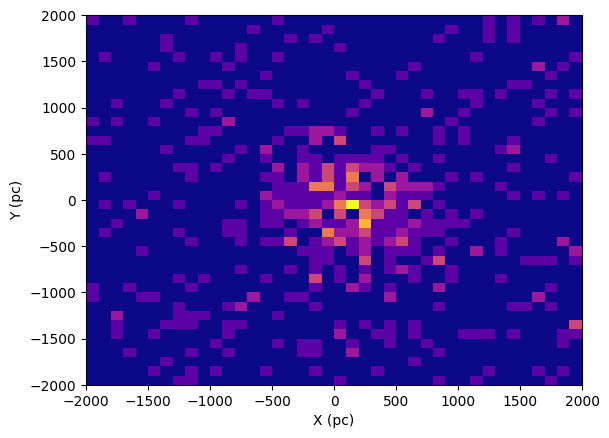

In [4]:
plt.figure()
plt.scatter(df['X_pc'], df['Y_pc'], s=1)

plt.xlabel("X (pc)")
plt.ylabel("Y (pc)")


plt.figure()
plt.hist2d(df['X_pc'], df['Y_pc'], bins=100, cmap='plasma')

plt.xlabel("X (pc)")
plt.ylabel("Y (pc)")


plt.figure()
plt.hist2d(df['X_pc'], df['Y_pc'], bins=100, cmap='plasma')

plt.xlabel("X (pc)")
plt.ylabel("Y (pc)")


plt.xlim(-2000, 2000)
plt.ylim(-2000, 2000)


Text(0.5, 0, 'v (km/s)')

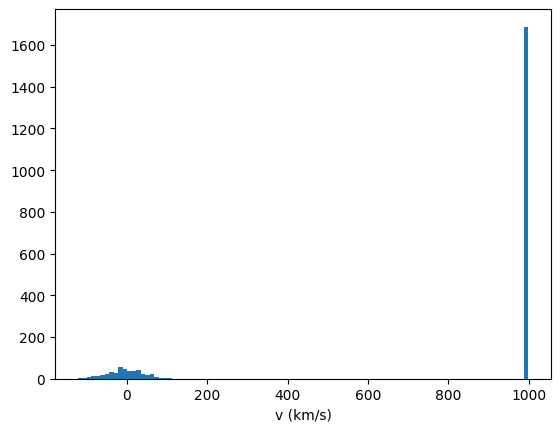

In [5]:
plt.figure()
plt.hist(df['vr'], bins=100);

plt.xlabel("v (km/s)")


# plt.xlim(-2000, 2000)


Text(0.5, 0, 'v (km/s)')

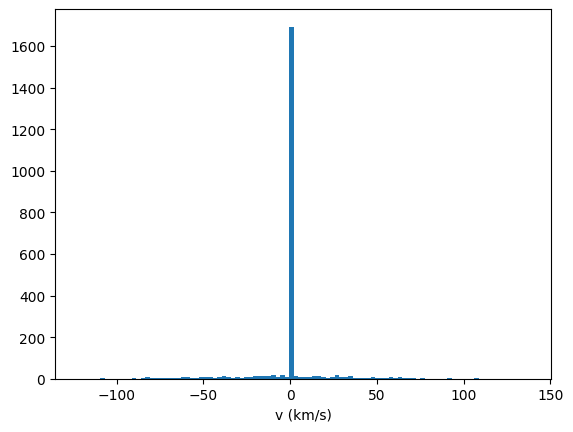

In [6]:
ind_novr = df['vr'] > 990
df.loc[ind_novr, 'vr'] = 0
df.loc[ind_novr, 'd_vr'] = 10000

plt.figure()
plt.hist(df['vr'], bins=100);

plt.xlabel("v (km/s)")

In [7]:
def new_coords(x, y, alpha):

    x_new = x * np.cos(alpha) + y * np.sin(alpha)
    y_new = - x * np.sin(alpha) + y * np.cos(alpha)

    return x_new, y_new

# define the two axis of the ellipse using sigma_x, sigma_y, and alpha (change within pi/2)

def log_Likelihood(theta, x, y, vr, e_vr):

    xc, yc, sigma_x, sigma_y, alpha, mvr_dg, dvr_dg, mvr_mw, dvr_mw, f = theta

    x1, y1 = new_coords(x, y, alpha)
    xc1, yc1 = new_coords(xc, yc, alpha)

    sigma_v_dg = np.sqrt(dvr_dg**2 + e_vr**2)
    sigma_v_mw = np.sqrt(dvr_mw**2 + e_vr**2)

    # Calculate the likelihood of being in the dwarf galaxy
    L_dg_xy = 1/(2*np.pi*sigma_x * sigma_y)*np.exp(-0.5*((x1-xc1)**2./sigma_x**2.+(y1-yc1)**2./sigma_y**2.))
    L_dg_vr = 1/(2*np.pi*sigma_v_dg)*np.exp(-0.5*((vr-mvr_dg)**2./sigma_v_dg**2))

    L_dg = L_dg_xy * L_dg_vr
    # Calculate the likelihood of being in the MW foreground
    L_mw_xy = 1/10000**2.
    L_mw_vr = 1/(2*np.pi*sigma_v_mw)*np.exp(-0.5*((vr-mvr_mw)**2./sigma_v_mw**2))
    L_mw = L_mw_xy * L_mw_vr
    
    logL = np.sum(np.log(f*L_dg + (1-f)*L_mw))

    return logL


In [8]:
xc0 = 0
yc0 = 0
sigma_x0 = 100
sigma_y0 = 100
alpha0 = 0
mvr_dg0 = -20.0
dvr_dg0 = 10.0
mvr_mw0 = 0
dvr_mw0 = 50.0
f0=0.1

param0 = xc0, yc0, sigma_x0, sigma_y0, alpha0, mvr_dg0, dvr_dg0, mvr_mw0, dvr_mw0, f0

logL0 = log_Likelihood(param0, df['X_pc'], df['Y_pc'], df['vr'], df['d_vr'])

# refine the following steps based on the uncertainties of the results
step_xc = 10
step_yc = 10
step_sigma_x = 10
step_sigma_y = 10
step_alpha = np.pi/20
step_mvr_dg = 2
step_dvr_dg = 2
step_mvr_mw = 5
step_dvr_mw = 2
step_f = 0.005
nsteps = 100000

samples = np.zeros((nsteps, 12))
accept = 1

In [9]:
for i in range(nsteps):

    param1 = param0
    logL1 = logL0

    samples[i, :10] = param1
    samples[i, 10] = logL1
    samples[i, 11] = accept

    accept = 0

    xc1, yc1, sigma_x1, sigma_y1, alpha1, mvr_dg1, dvr_dg1, mvr_mw1, dvr_mw1, f1 = param1
    xc1 = xc1 + np.random.normal(0, step_xc)   
    yc1 = yc1 + np.random.normal(0, step_yc)
    sigma_x1 = sigma_x1 + np.random.normal(0, step_sigma_x)
    sigma_y1 = sigma_y1 + np.random.normal(0, step_sigma_y)
    alpha1 = alpha1 + np.random.normal(0, step_alpha)
    

    mvr_dg1 = mvr_dg1 + np.random.normal(0, step_mvr_dg)
    dvr_dg1 = dvr_dg1 + np.random.normal(0, step_dvr_dg)   
    mvr_mw1 = mvr_mw1 + np.random.normal(0, step_mvr_mw)
    dvr_mw1 = dvr_mw1 + np.random.normal(0, step_dvr_mw)
    f1 = f1 + np.random.normal(0, step_f)
   
     # assuming the axis changing from 0 to pi/2, may need to adjust to (-pi/4 to pi/4) for some dwarfs
    alpha_min = 0.
    alpha_max = np.pi/2.

    if all([
            0 < f1 < 1,
            0 < sigma_x1 < 1000,
            0 < sigma_y1 < 1000,
            alpha_min <= alpha1 < alpha_max,
            -300 < mvr_dg1 < 300,
            -100 < mvr_mw1 < 100,
            0 < dvr_dg1 < 30,
            20 < dvr_mw1 < 60,
    ]):    
        
        param1 = xc1, yc1, sigma_x1, sigma_y1, alpha1, mvr_dg1, dvr_dg1, mvr_mw1, dvr_mw1, f1
        logL1 = log_Likelihood(param1,  df['X_pc'], df['Y_pc'], df['vr'], df['d_vr'])      

        if logL1 > logL0:

            param0 = param1
            logL0 = logL1
            accept = 1

        else:

            a = np.random.uniform(0, 1)
            if (logL1-logL0) > np.log(a):

                param0 = param1
                logL0 = logL1
                accept = 1

In [10]:
# Check the acceptance rate of the MCMC (should be around 20%)
ind_accept = samples[:, -1] == 1
print ("acceptance rate", len(samples[ind_accept, -1])/nsteps)
samples =  samples[int(nsteps*0.1):]


acceptance rate 0.17629


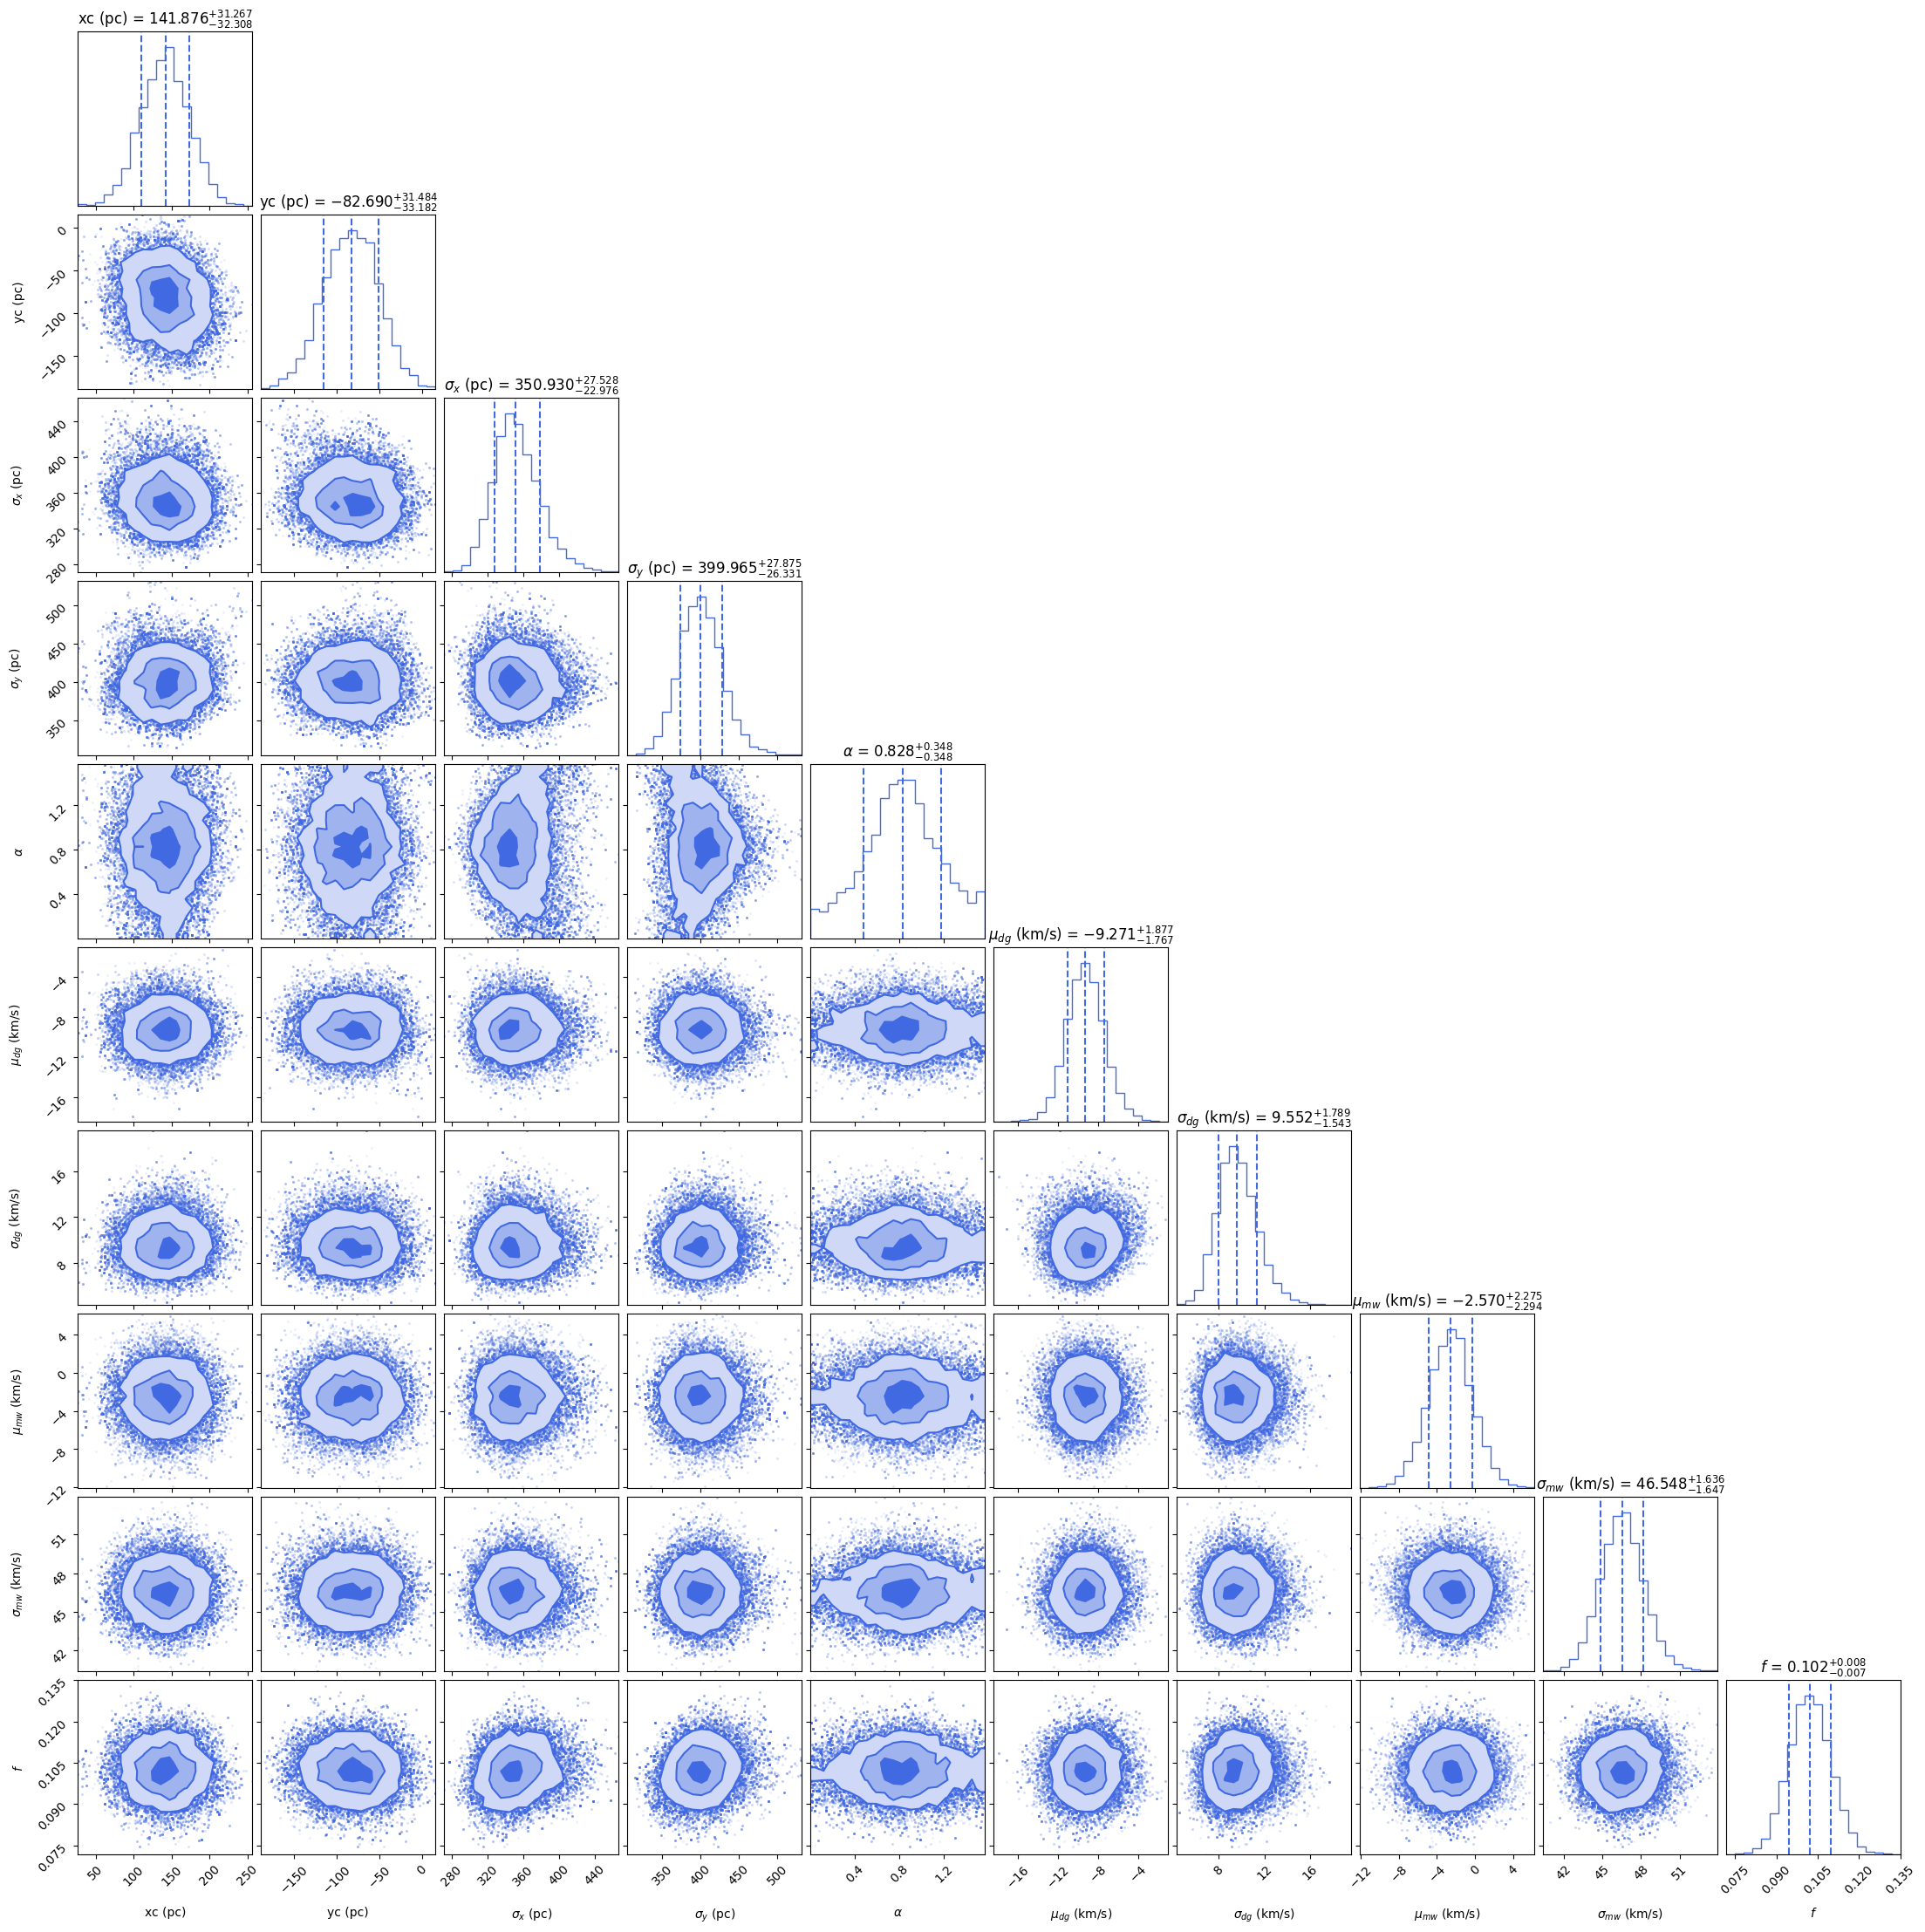

In [11]:
figure_path="../figure/"
fig = corner.corner(
    samples[:,:10],
    labels=[r"xc (pc)", r"yc (pc)", r"$\sigma_x$ (pc)", r"$\sigma_y$ (pc)", r"$\alpha$", r"$\mu_{dg}$ (km/s)", r"$\sigma_{dg}$ (km/s)", r"$\mu_{mw}$ (km/s)", r"$\sigma_{mw}$ (km/s)", r"$f$"],
    # truths=[mvr1_true, dvr1_true, mvr2_true, dvr2_true, f_true],  # optional
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    levels=(0.16, 0.5, 0.84),
    color="royalblue",
    fill_contours=True
)

plt.savefig(figure_path+'Dwarf_%02d_10D_MCMC_corner_new.png'%k, dpi=300)

In [12]:
np.savetxt(res_path+'Dwarf_%02d_10D_MCMC_chain.txt'%k, samples)

## Calculating the membership probabilities

In [68]:
def prob_member(theta, x, y, vr, e_vr ):

    xc, yc, sigma_x, sigma_y, alpha, mvr_dg, dvr_dg, mvr_mw, dvr_mw, f  = theta

    x1, y1 = new_coords(x, y, alpha)
    xc1, yc1 = new_coords(xc, yc, alpha)

    sigma_v_dg = np.sqrt(dvr_dg**2 + e_vr**2)
    sigma_v_mw = np.sqrt(dvr_mw**2 + e_vr**2)

    P_dg_xy = 1/(2*np.pi*sigma_x * sigma_y)*np.exp(-0.5*((x1-xc1)**2./sigma_x**2.+(y1-yc1)**2./sigma_y**2.))
    P_dg_vr = 1/(2*np.pi*sigma_v_dg)*np.exp(-0.5*((vr-mvr_dg)**2./sigma_v_dg**2))

    P_dg = P_dg_xy * P_dg_vr

    P_mw_xy = 1/10000**2.
    P_mw_vr = 1/(2*np.pi*sigma_v_mw)*np.exp(-0.5*((vr-mvr_mw)**2./sigma_v_mw**2))
    P_mw = P_mw_xy * P_mw_vr
    
    
    prob =P_dg / (P_dg + P_mw)

    return prob


In [69]:
p_member = np.zeros(len(df))
indices = np.random.choice(len(samples), 1000, replace=False)
print(indices.shape)
draw_samples = samples[indices]



for i in range(len(draw_samples)):

    param = draw_samples[i,:10]

    p_member += prob_member(param, df['X_pc'], df['Y_pc'], df['vr'], df['d_vr'])

p_member = p_member/len(draw_samples)
df['P_member'] = p_member



(1000,)


Text(0.5, 0, 'Probability of being a member of Dwarf01')

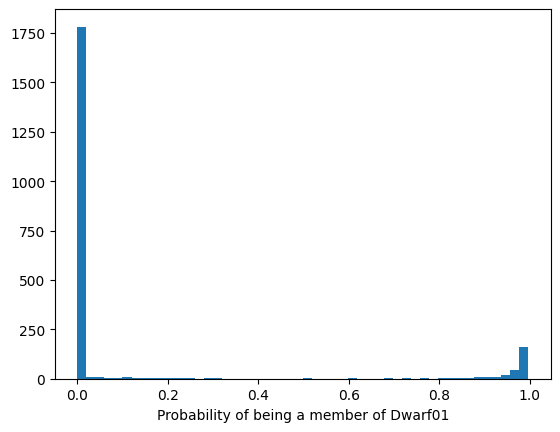

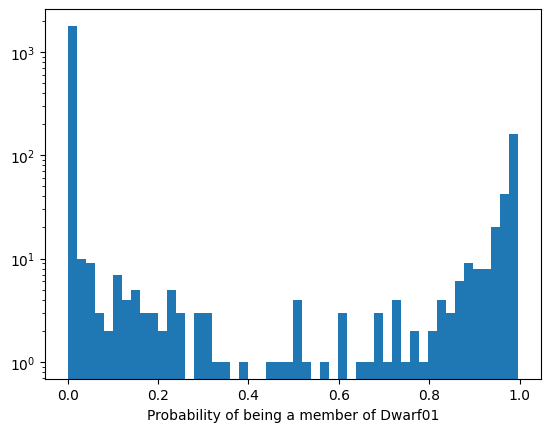

In [70]:
plt.figure()
plt.hist(p_member, bins=50);
plt.xlabel("Probability of being a member of Dwarf%02d"%1)

plt.figure()
plt.hist(p_member, bins=50);
plt.yscale("log")
plt.xlabel("Probability of being a member of Dwarf%02d"%1)

Text(0, 0.5, 'Y (pc)')

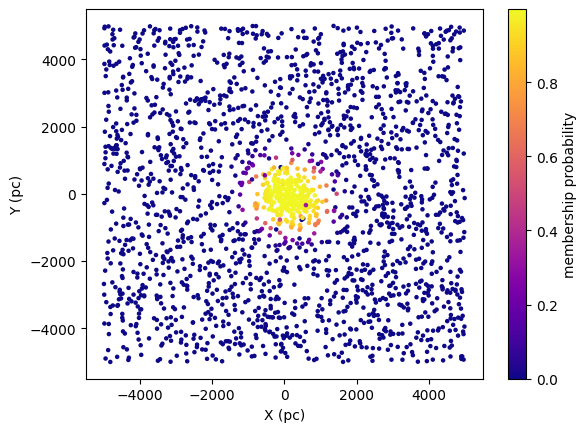

In [71]:
plt.figure()
im=plt.scatter(df['X_pc'], df['Y_pc'], c=df['P_member'], s=5, cmap='plasma')
cb=plt.colorbar(im)
cb.set_label("membership probability")

plt.xlabel("X (pc)")
plt.ylabel("Y (pc)")